In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')


In [4]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 120
NETFLIX_RED = '#E50914'
NETFLIX_DARK = '#221F1F'

In [5]:
df = pd.read_csv('netflix_titles.csv')
df.drop_duplicates(inplace=True)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('No Cast Info', inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df.dropna(subset=['duration'], inplace=True)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)

print(f"Data cleaned: {df.shape}")

Data cleaned: (8804, 15)


In [6]:
kids_ratings = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'PG', 'TV-G', 'TV-PG']

df['is_adult'] = df['rating'].apply(
    lambda x: 0 if x in kids_ratings else 1
)

print(f"\n Target Distribution:")
print(df['is_adult'].value_counts().rename({0: 'Kids', 1: 'Adult'}))
print(f"\nKids %: {round(df['is_adult'].eq(0).mean()*100, 1)}%")
print(f"Adult %: {round(df['is_adult'].eq(1).mean()*100, 1)}%")


 Target Distribution:
is_adult
Adult    6746
Kids     2058
Name: count, dtype: int64

Kids %: 23.4%
Adult %: 76.6%


In [7]:
df['type_encoded'] = (df['type'] == 'Movie').astype(int)

In [8]:
top_countries = df['country'].value_counts().head(10).index
df['country_encoded'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country_encoded'])

In [9]:
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
top_genres = df['primary_genre'].value_counts().head(15).index
df['genre_encoded'] = df['primary_genre'].apply(
    lambda x: x if x in top_genres else 'Other'
)
le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['genre_encoded'])

In [11]:
le_type = LabelEncoder()
df['type_encoded'] = le_type.fit_transform(df['type'])

print("Feature engineering done")
print(f"\nFeatures created: type_encoded, country_encoded, genre_encoded")


Feature engineering done

Features created: type_encoded, country_encoded, genre_encoded


In [13]:
features = [
    'type_encoded',
    'country_encoded',
    'genre_encoded',
    'year_added',
    'month_added',
    'duration_value',
    'release_year'
]

X = df[features]
y = df['is_adult']

print(f"\n Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")


 Feature matrix shape: (8804, 7)
Target shape: (8804,)

 Train size: 7043
Test size: 1761
Features scaled


In [16]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42, max_depth=8
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42,
        n_estimators=100, max_depth=10
    )
}



results = {}

print("\n" + "=" * 55)
print("       MODEL TRAINING & EVALUATION RESULTS")
print("=" * 55)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Kids', 'Adult'])

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc
    }

    print(f"\n {name}")
    print(f"   Accuracy: {acc*100:.2f}%")
    print(f"\n{report}")
    print("-" * 55)

print("\n Best Model:", max(results, key=lambda x: results[x]['accuracy']))


       MODEL TRAINING & EVALUATION RESULTS

 Logistic Regression
   Accuracy: 61.04%

              precision    recall  f1-score   support

        Kids       0.34      0.72      0.46       412
       Adult       0.87      0.58      0.69      1349

    accuracy                           0.61      1761
   macro avg       0.61      0.65      0.58      1761
weighted avg       0.75      0.61      0.64      1761

-------------------------------------------------------

 Decision Tree
   Accuracy: 81.83%

              precision    recall  f1-score   support

        Kids       0.60      0.68      0.64       412
       Adult       0.90      0.86      0.88      1349

    accuracy                           0.82      1761
   macro avg       0.75      0.77      0.76      1761
weighted avg       0.83      0.82      0.82      1761

-------------------------------------------------------

 Random Forest
   Accuracy: 85.69%

              precision    recall  f1-score   support

        Kids      

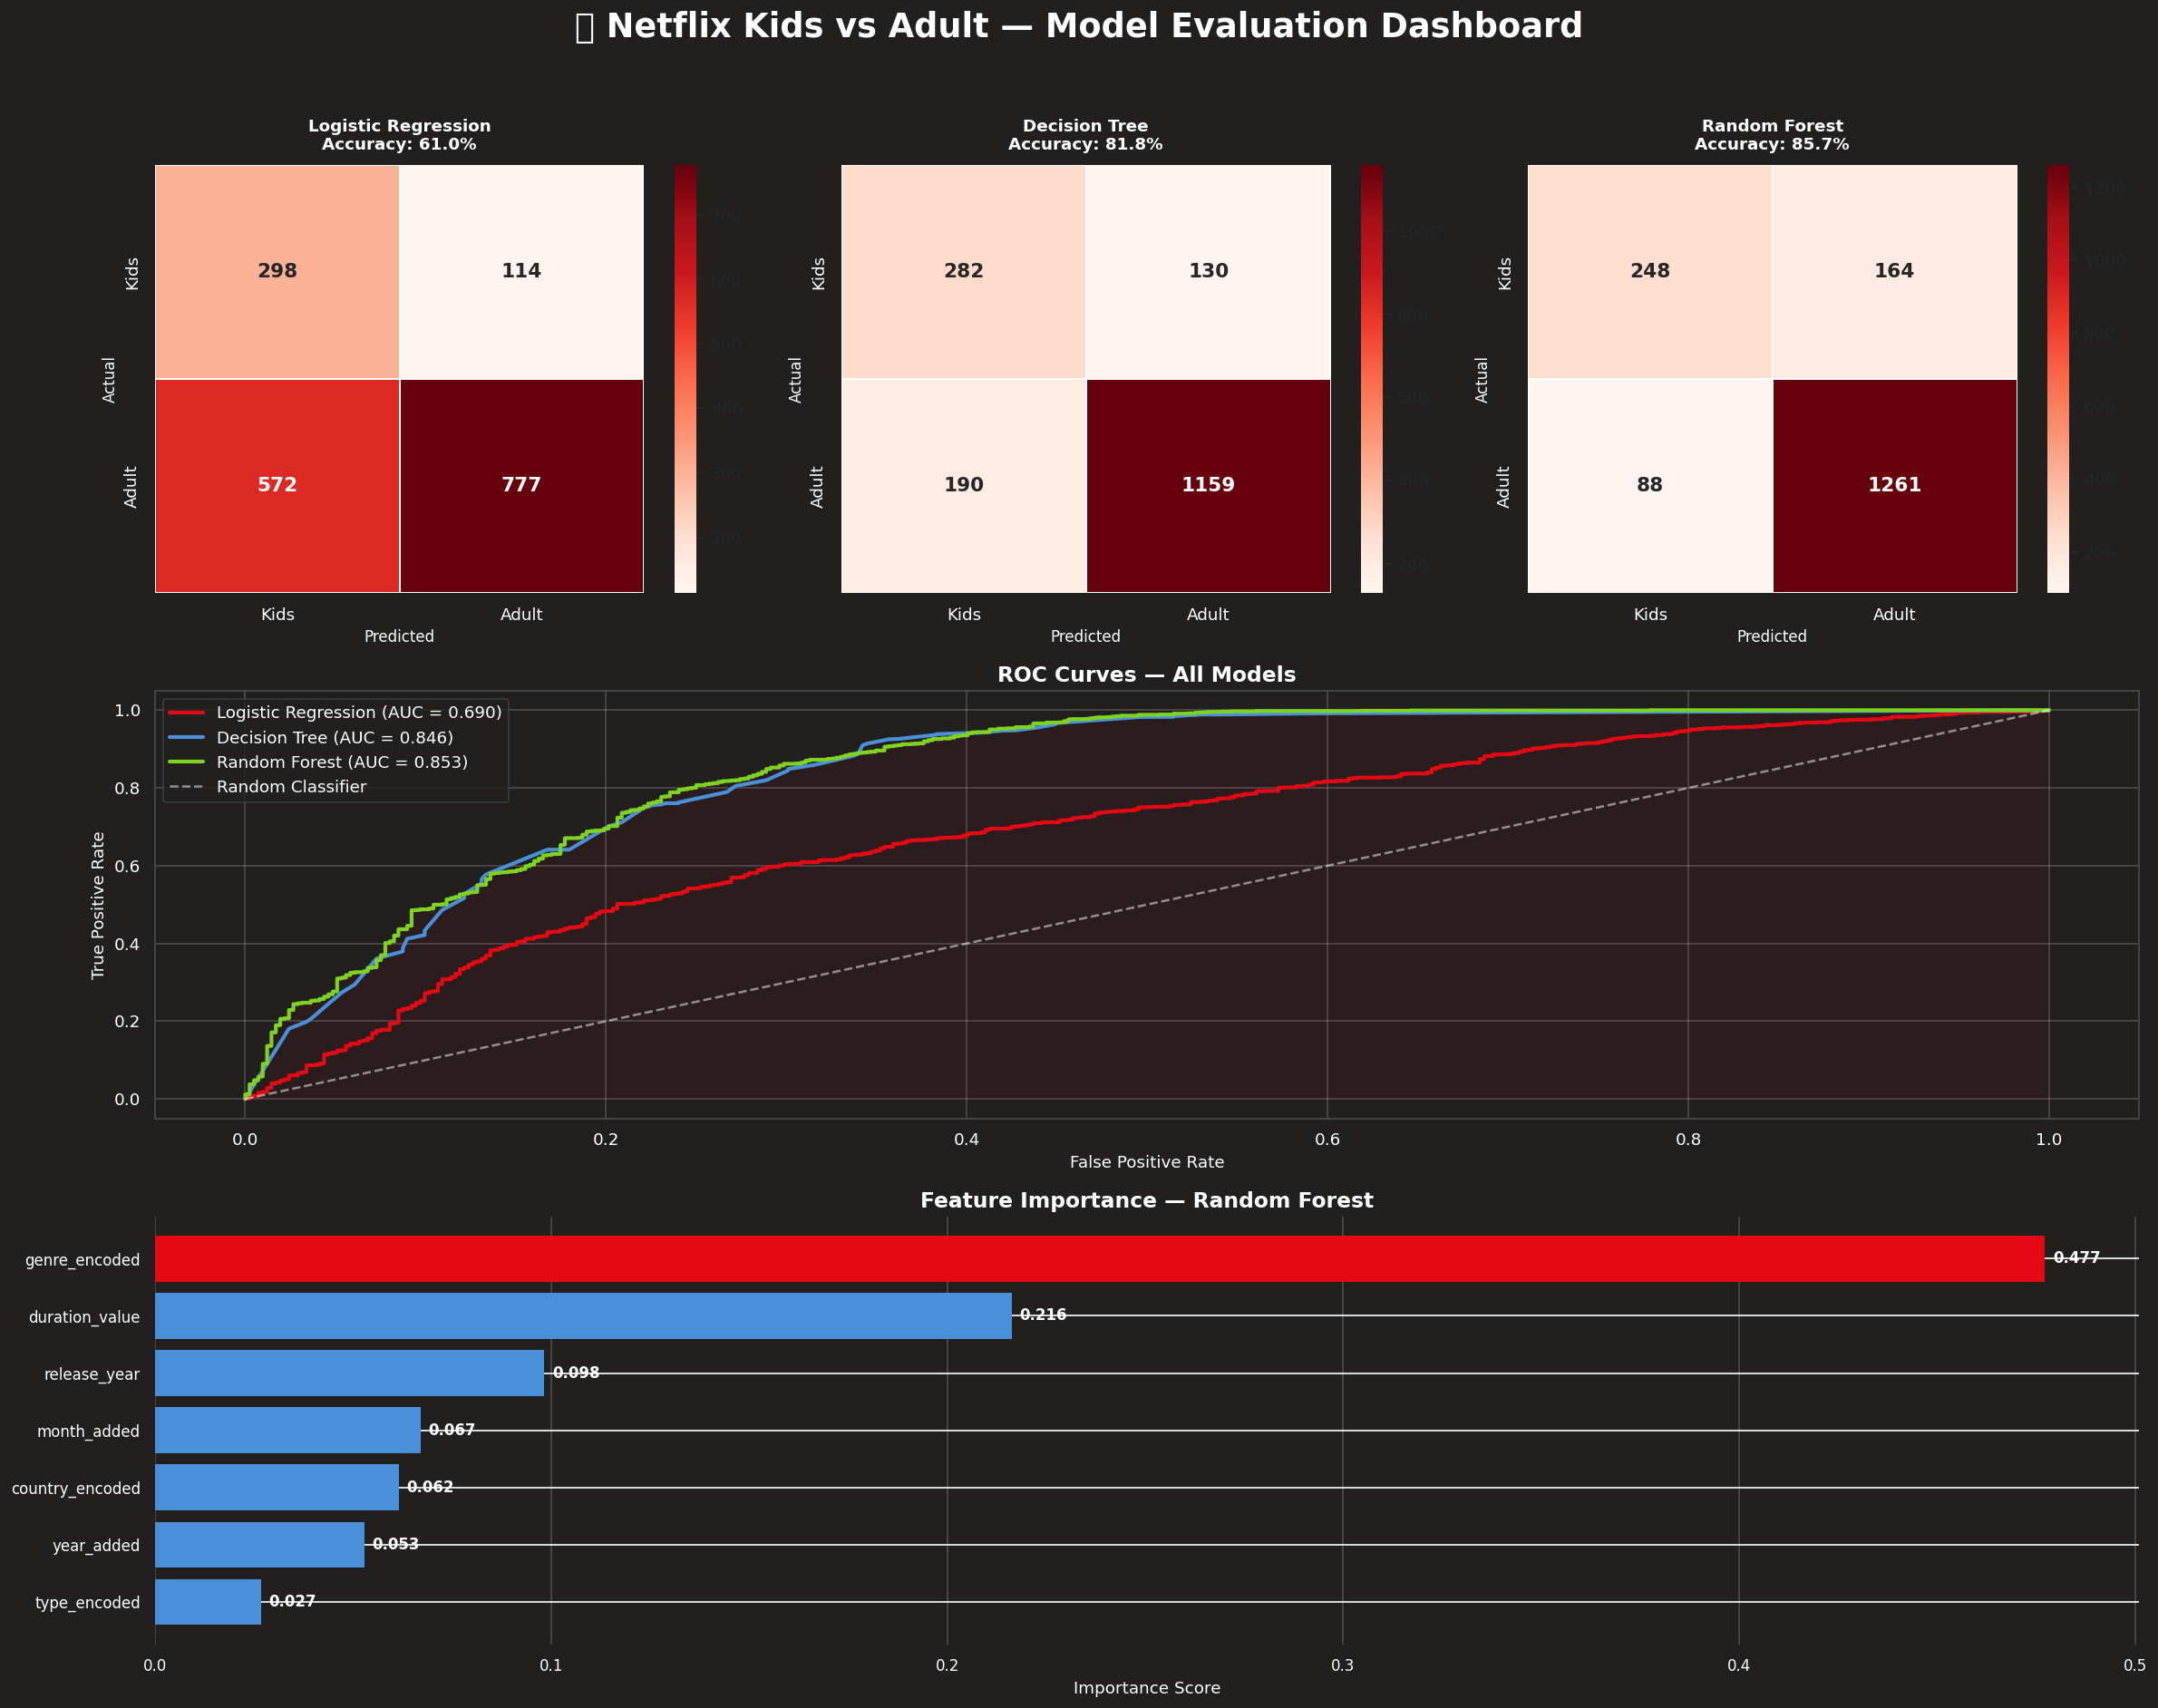

🎉 Model evaluation dashboard saved!


In [15]:


fig = plt.figure(figsize=(20, 16), facecolor=NETFLIX_DARK)
fig.suptitle('🎬 Netflix Kids vs Adult — Model Evaluation Dashboard',
             fontsize=22, fontweight='bold', color='white', y=0.98)

# CHART 1 — Confusion Matrices (all 3)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
for idx, name in enumerate(model_names):
    ax = fig.add_subplot(3, 3, idx + 1)
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Kids', 'Adult'],
                yticklabels=['Kids', 'Adult'],
                ax=ax, linewidths=1,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'{name}\nAccuracy: {results[name]["accuracy"]*100:.1f}%',
                 fontsize=11, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Predicted', color='white', fontsize=10)
    ax.set_ylabel('Actual', color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.set_facecolor(NETFLIX_DARK)

# ── CHART 2 — ROC Curves (all 3) ──────────────
ax_roc = fig.add_subplot(3, 1, 2)
colors = [NETFLIX_RED, '#4A90D9', '#7ED321']

for name, color in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{name} (AUC = {roc_auc:.3f})')

ax_roc.plot([0, 1], [0, 1], 'white', linestyle='--',
            linewidth=1.5, alpha=0.5, label='Random Classifier')
ax_roc.fill_between(fpr, tpr, alpha=0.05, color=NETFLIX_RED)
ax_roc.set_title('ROC Curves — All Models', fontsize=14,
                 fontweight='bold', color='white')
ax_roc.set_xlabel('False Positive Rate', color='white', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', color='white', fontsize=11)
ax_roc.tick_params(colors='white')
ax_roc.set_facecolor(NETFLIX_DARK)
ax_roc.spines[:].set_color('#444')
ax_roc.legend(fontsize=11, facecolor=NETFLIX_DARK,
              labelcolor='white', edgecolor='#444')
ax_roc.grid(True, alpha=0.2, color='white')

# ── CHART 3 — Feature Importance (Random Forest) ──
ax_fi = fig.add_subplot(3, 1, 3)
rf_model = results['Random Forest']['model']
importances = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=True)

colors_fi = [NETFLIX_RED if i == len(importances)-1
             else '#4A90D9' for i in range(len(importances))]
bars = ax_fi.barh(importances.index, importances.values,
                  color=colors_fi, edgecolor='none')

for bar, val in zip(bars, importances.values):
    ax_fi.text(val + 0.002, bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', va='center', fontsize=10,
               color='white', fontweight='bold')

ax_fi.set_title('Feature Importance — Random Forest',
                fontsize=14, fontweight='bold', color='white')
ax_fi.set_xlabel('Importance Score', color='white', fontsize=11)
ax_fi.set_facecolor(NETFLIX_DARK)
ax_fi.tick_params(colors='white', labelsize=10)
ax_fi.spines[:].set_visible(False)
ax_fi.grid(True, alpha=0.2, color='white', axis='x')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('task2_model_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_DARK)
plt.show()
print("🎉 Model evaluation dashboard saved!")